# L5b Advanced: Rolling Correlations

The multiple-asset geometric Brownian motion model of L5b assumes a constant covariance rate $\mathbf{C}$, so the modeled volatilities and correlations never change. In L4b, we saw that constant volatility misses the clustering of large price movements. Does a constant correlation hold up any better over our historical sample?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Estimate rolling correlations:** Compute the correlation between two assets' growth rates over a window that moves forward one trading day at a time. Explain why shorter windows react faster but give noisier estimates.
>
> * **Compute exponentially weighted correlations:** Estimate correlations that give recent observations more weight and let older ones fade gradually. Explain how the decay factor controls how long old observations continue to matter.
>
> * **Compare correlation and market volatility:** Compare the average correlation across many asset pairs with SPY volatility over the same windows. Explain why a covariance estimate from a calm period may understate risk in a volatile one.

In this example, we track correlations for three asset pairs in the 2014–2024 training data. We then compare the average correlation across 100 assets with market volatility.

Let's get started!

___


## Setup, Data, and Prerequisites

First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project and loads the packages used to prepare the data, calculate correlations, and plot the results. It also loads the local helper functions from `src/`.

Let's set up our code environment:


In [1]:
# Load packages and the local rolling/EWMA correlation functions from src/ -
include(joinpath(@__DIR__, "Include.jl")); # resolve the example's own setup file

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

Let's set the plotting defaults for the figures below:


In [2]:
# Apply a common visual style to the rolling, EWMA, and market-condition figures -
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

### Data

Our training dataset contains daily prices for S&P 500 stocks, along with several exchange-traded funds and volatility products, from January 3, 2014 through December 31, 2024. We use each asset's volume-weighted average price.

[The MyTrainingMarketDataSet() function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) loads the data as a dictionary indexed by ticker. We keep only the assets with a complete price history, the same length as `AAPL`, and sort their tickers to fix the column order. We also check that every retained asset has the same trading dates as `AAPL`, so that each row compares growth rates from the same day. The retained records go in `dataset` and the ordered tickers in `list_of_tickers`:


In [ ]:
# Retain complete histories, then verify that equal-length rows refer to the same dates -
dataset, list_of_tickers = let
    original_dataset = MyTrainingMarketDataSet()["dataset"]; # Daily price records indexed by ticker.
    maximum_number_trading_days = nrow(original_dataset["AAPL"]); # Length of the complete price history.
    dataset = Dict(
        ticker => records for (ticker, records) in original_dataset
        if nrow(records) == maximum_number_trading_days
    );
    list_of_tickers = sort(collect(keys(dataset))); # Fixed column order for the growth-rate matrix.
    reference_timestamps = dataset["AAPL"][!, :timestamp]; # Trading dates shared by the retained assets.

    # Correlations require observations from the same trading intervals.
    @assert all(
        dataset[ticker][!, :timestamp] == reference_timestamps
        for ticker in list_of_tickers
    ) "Retained assets must have matching trading dates."

    (dataset, list_of_tickers) # return data and its fixed column order together
end;

### Construct the Growth-Rate Matrix

For asset $i$ with prices $S_{k-1}^{(i)}$ and $S_k^{(i)}$ on successive trading days, and $\Delta t=1/252$ years per trading day, the growth rate is given by:
$$
g_k^{(i)}=\frac{1}{\Delta t}\ln\!\left(\frac{S_k^{(i)}}{S_{k-1}^{(i)}}\right).
$$
This is the one-day log return expressed in inverse years. An interval that spans a weekend still counts as one trading-day step.

[The log_growth_matrix(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) stores these rates in $\mathbf{G}\in\mathbb{R}^{N\times M}$, with one row per trading interval and one column per asset, in `list_of_tickers` order. The vector `dates` labels each row with its interval's ending date, so the dates start at the second price record:


In [ ]:
# Convert consecutive prices to growth rates using trading time, including across weekends -
Δt = 1.0/252.0; # Time per trading day, in years.
G = log_growth_matrix(dataset, list_of_tickers; Δt = Δt); # Growth rates, in inverse years.
dates = Date.(dataset["AAPL"][2:end, :timestamp]); # Row k of G uses price rows k and k+1; label it by row k+1's date.
N = size(G, 1); # Number of growth-rate observations.
M = size(G, 2); # Number of retained assets.

println(
    "N = $(N) growth-rate observations for M = $(M) assets, ",
    "$(first(dates)) to $(last(dates))",
);

N = 2766 growth-rate observations for M = 424 assets, 2014-01-06 to 2024-12-31


___

## Task 1: Estimate Rolling Correlations

In this task, we estimate correlations for three asset pairs over 63-day and 252-day windows and compare them with the full-sample correlation. A single full-sample value summarizes the whole record. Rolling windows show how the relationship changes from one period to the next.

### Calculate Correlation Within a Window

A window of $L$ observations ending at row $k$ of $\mathbf{G}$ uses rows $k-L+1,\ldots,k$. Moving forward one day adds the newest row and drops the oldest. Within the window, the sample mean of asset $i$ (marked with a prime) is given by:
$$
g'_i(k)=\frac{1}{L}\sum_{q=k-L+1}^{k}g_q^{(i)}.
$$
The sample covariance averages the products of the two assets' deviations from their window means:
$$
\hat{\Sigma}_{g,ij}(k)
=\frac{1}{L-1}\sum_{q=k-L+1}^{k}
\bigl(g_q^{(i)}-g'_i(k)\bigr)
\bigl(g_q^{(j)}-g'_j(k)\bigr).
$$
Setting $i=j$ gives the variance. Dividing the covariance by the two standard deviations gives the rolling correlation:
$$
\hat{\rho}_{ij}(k)
=\frac{\hat{\Sigma}_{g,ij}(k)}
{\sqrt{\hat{\Sigma}_{g,ii}(k)\,\hat{\Sigma}_{g,jj}(k)}}.
$$
The correlation lies between $-1$ and $1$. A positive value means the two growth rates tend to move above or below their window means together. A negative value means their deviations from the window means tend to have opposite signs.


### Compare Short and Long Windows

A 63-day window covers about one quarter, and a 252-day window covers about one year. The shorter window reacts faster but averages fewer observations, so its estimate is noisier.

How noisy? Suppose the true correlation $\rho$ never changes and each day's pair of growth rates is an independent draw from a bivariate normal distribution. A window estimate then has a standard error of about $(1-\rho^2)/\sqrt{L}$. At $\rho=0.5$ and $L=63$, this is about $0.094$, so a 63-day estimate can differ from the true correlation by about $0.1$ even when nothing has changed.

We compare three pairs: two chip makers (AMD and NVDA), a bank and an oil company (JPM and XOM), and an S&P 500 fund and a gold fund (SPY and GLD). [The rolling_correlation(...) function](docs/rolling-correlation.md#rolling_correlation) computes the window correlation on each date and returns `NaN` until the first full window is available. We store the rolling estimates in `rolling_df` and each pair's full-sample correlation in `full_sample`:


In [4]:
# Choose pair/window combinations and map each ticker to its column of G -
pairs = [("AMD", "NVDA"), ("JPM", "XOM"), ("SPY", "GLD")]; # Asset pairs to compare.
window_lengths = (63, 252); # Window lengths, in trading days.
column_index = Dict(ticker => i for (i, ticker) in enumerate(list_of_tickers)); # Ticker-to-column lookup.

rolling_df = let
    df = DataFrame(date = dates); # one row per growth interval, even before a complete window exists
    for (a, b) in pairs, L in window_lengths
        x = G[:, column_index[a]]; # First asset's growth rates, in inverse years.
        y = G[:, column_index[b]]; # Second asset's growth rates, in inverse years.
        # Entry k uses rows k-L+1:k; the first L-1 entries are NaN, not zero correlations.
        df[!, "$(a)-$(b) L=$(L)"] = rolling_correlation(x, y, L);
    end
    df
end;

# Compute one full-history reference per pair; it includes dates beyond earlier rolling endpoints.
full_sample = Dict(
    "$(a)-$(b)" => cor(G[:, column_index[a]], G[:, column_index[b]])
    for (a, b) in pairs
)

Dict{String, Float64} with 3 entries:
  "AMD-NVDA" => 0.58746
  "SPY-GLD"  => 0.0189938
  "JPM-XOM"  => 0.529183

The dashed line in each panel marks the pair's full-sample correlation:


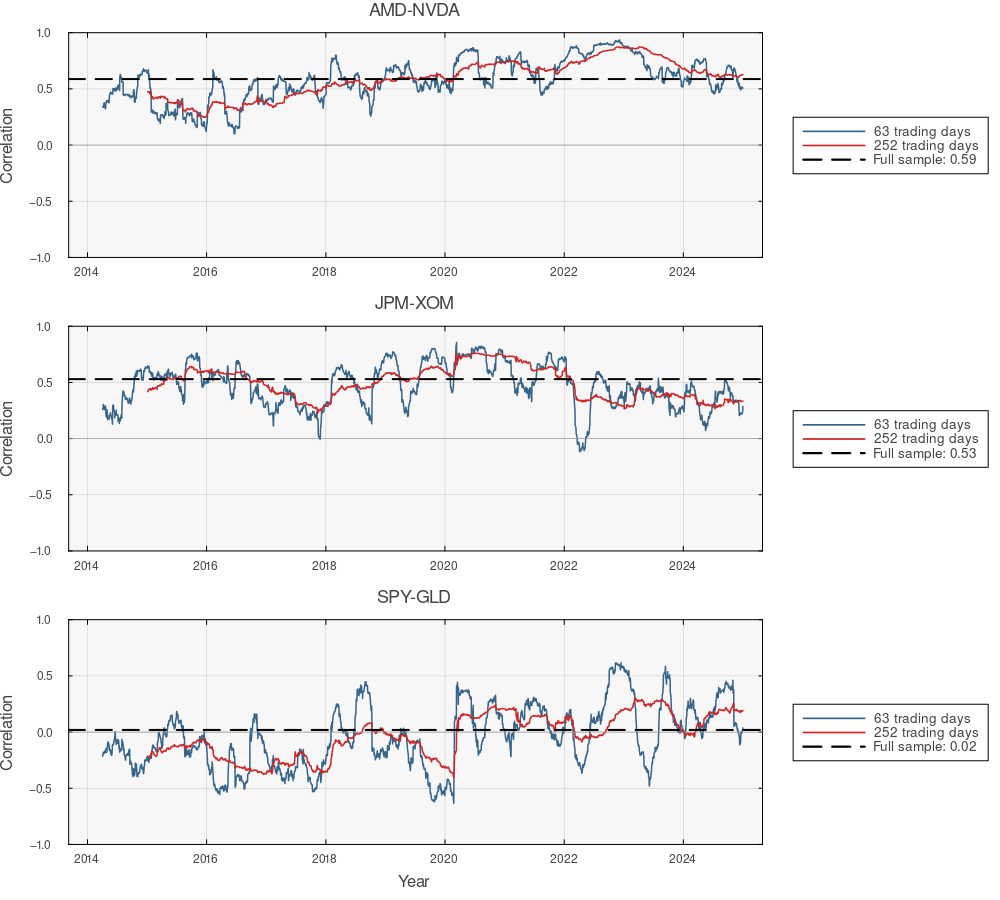

In [ ]:
let
    panels = []; # collect one panel per asset pair
    line_colors = (:steelblue4, :firebrick3); # Colors for the short and long windows.
    for (a, b) in pairs
        key = "$(a)-$(b)"; # Pair label used in the result dictionaries.
        p = plot(
            title = key,
            titlefontsize = 12,
            ylabel = "Correlation",
            ylims = (-1.0, 1.0),
            yticks = -1.0:0.5:1.0,
            xticks = (Date.(2014:2:2024), string.(2014:2:2024)),
            legend = :outerright,
            legendfontsize = 9,
        );
        # Pair each window with its color; plotting skips the leading undefined (NaN) estimates.
        for (L, color) in zip(window_lengths, line_colors)
            plot!(
                p, rolling_df.date, rolling_df[!, "$(key) L=$(L)"];
                color = color,
                linewidth = 1.5,
                label = "$(L) trading days",
            );
        end
        # Add the full-history benchmark for context; it is not a real-time estimate.
        hline!(
            p, [full_sample[key]];
            color = :black,
            linestyle = :dash,
            label = "Full sample: $(round(full_sample[key], digits = 2))",
        );
        hline!(p, [0.0]; color = :gray60, linewidth = 0.7, label = false);
        push!(panels, p);
    end
    plot!(panels[end]; xlabel = "Year");
    # Align calendar dates across panels so movements can be compared at the same times.
    plot(panels...; layout = (3, 1), size = (1000, 900), link = :x)
end

### Read the Comparison

For the default pairs, the chip makers stay positively correlated, but the strength of the relationship changes a lot. The bank and oil company are positively correlated over the full sample, yet their 63-day estimate briefly turns negative. The index and gold funds have a full-sample correlation near zero, but their rolling estimates spend long stretches clearly positive or negative. A single full-sample number hides all of this. Keep in mind that adjacent 63-day windows share 62 observations, and part of the movement is sampling noise.

Next, we try an estimator that fades old observations gradually instead of dropping them at the window edge.

___

## Task 2: Estimate Exponentially Weighted Correlations

In this task, we compute exponentially weighted (EWMA) correlations for the first pair from Task 1 and compare them with its 63-day rolling estimate. Instead of a hard window cutoff, an EWMA gives recent observations more weight and lets older ones fade gradually.

### Update the Covariance and Correlation

Following the [RiskMetrics convention](https://www.msci.com/documents/10199/5915b101-4206-4ba0-aee2-3449d5c7e95a), we treat the daily mean growth rate as zero because it is small compared with the day-to-day variation. For a decay factor $0<\lambda<1$, the covariance estimate is updated each day by:
$$
\hat{\Sigma}^{\mathrm{EW}}_{g,ij}(k)
=\underbrace{\lambda\,\hat{\Sigma}^{\mathrm{EW}}_{g,ij}(k-1)}_{\text{previous estimate}}
+\underbrace{(1-\lambda)\,g_k^{(i)}g_k^{(j)}}_{\text{new observation}}.
$$
Setting $i=j$ gives the variance update. The correlation is the covariance divided by the two standard deviations:
$$
\hat{\rho}^{\mathrm{EW}}_{ij}(k)
=\frac{\hat{\Sigma}^{\mathrm{EW}}_{g,ij}(k)}
{\sqrt{\hat{\Sigma}^{\mathrm{EW}}_{g,ii}(k)\,\hat{\Sigma}^{\mathrm{EW}}_{g,jj}(k)}}.
$$
We start the recursion with the plain average of the first $b=63$ products:
$$
\hat{\Sigma}^{\mathrm{EW}}_{g,ij}(b)
=\frac{1}{b}\sum_{q=1}^{b}g_q^{(i)}g_q^{(j)}.
$$
Each update uses only past data, so no future observations enter an estimate.


### Interpret the Decay Factor

Each day, an older observation's weight is multiplied by $\lambda$. The __decay time__ is the number of trading days for that weight to fall to $e^{-1}$, about 37% of its starting value:
$$
\tau_\lambda=-\frac{1}{\ln\lambda}
\approx\frac{1}{1-\lambda}.
$$
The __equivalent observation count__ is the number of equally weighted observations whose simple average would have the same variance as this weighted average, assuming independent observations with equal variance. With weight $w_m=(1-\lambda)\lambda^m$ on the observation from $m$ days earlier, this count is given by:
$$
N_{\mathrm{eff}}
=\frac{1}{\sum_{m=0}^{\infty}w_m^2}
=\frac{1+\lambda}{1-\lambda}.
$$
For our two decay factors:

| Decay factor | Weight on newest observation | Approximate decay time | Equivalent observation count |
| ---: | ---: | ---: | ---: |
| $0.94$ | $6\%$ | $17$ trading days | $32$ |
| $0.99$ | $1\%$ | $100$ trading days | $199$ |

A smaller $\lambda$ reacts faster but averages over fewer effective observations, so its estimate is noisier.

[The ewma_correlation(...) function](docs/ewma-correlation.md#ewma_correlation) runs the initialization and the daily updates. We store the rolling estimate and both EWMA estimates in `ewma_df`:


In [ ]:
# Compare estimators for the same pair and initial observation count -
ewma_pair = first(pairs); # Asset pair selected in Task 1.
comparison_window = first(window_lengths); # Rolling comparison window, in trading days.
burn_in = comparison_window; # Number of observations used to initialize the second moments.
decay_factors = (0.94, 0.99); # Dimensionless decay factors for the two EWMA estimates.

ewma_df = let
    a, b = ewma_pair;
    x = G[:, column_index[a]]; # First asset's growth rates, in inverse years.
    y = G[:, column_index[b]]; # Second asset's growth rates, in inverse years.
    df = DataFrame(
        date = dates,
        rolling = rolling_df[!, "$(a)-$(b) L=$(comparison_window)"],
    );
    # Initialize uncentered moments from the burn-in block, then update using only new observations.
    # The helper assumes zero mean; changing the weighting is not the only difference from rolling cor.
    for decay in decay_factors
        df[!, "EWMA λ=$(decay)"] = ewma_correlation(x, y, decay; burn_in = burn_in); # first burn_in-1 rows are NaN
    end
    df
end;

All three estimates start on the same date because they all use the same 63-observation start:

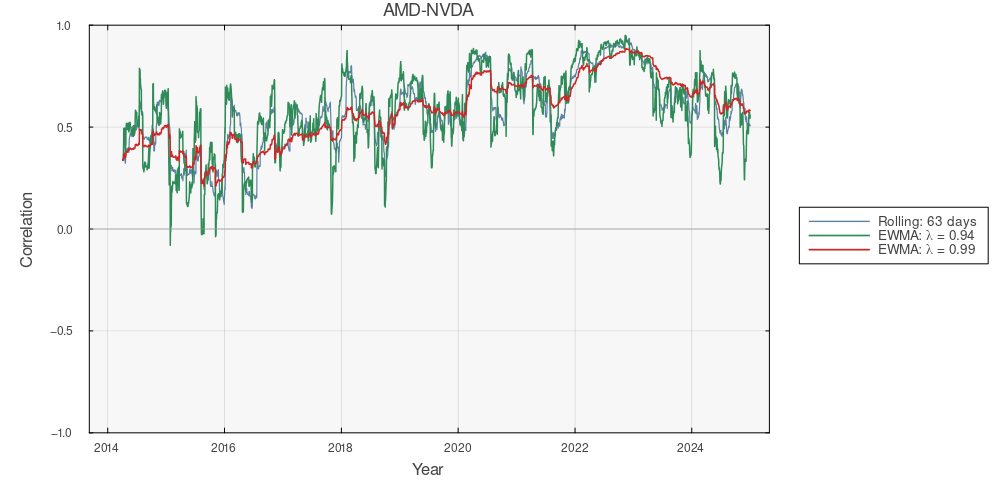

In [ ]:
let
    # Display centered rolling correlation alongside zero-mean exponentially weighted estimates -
    a, b = ewma_pair;
    line_colors = (:seagreen4, :firebrick3); # Colors for the shorter and longer EWMA memories.
    p = plot(
        ewma_df.date, ewma_df.rolling;
        color = :steelblue4,
        linewidth = 1.2,
        alpha = 0.8,
        label = "Rolling: $(comparison_window) days",
        title = "$(a)-$(b)",
        titlefontsize = 12,
        ylabel = "Correlation",
        xlabel = "Year",
        ylims = (-1.0, 1.0),
        yticks = -1.0:0.5:1.0,
        xticks = (Date.(2014:2:2024), string.(2014:2:2024)),
        size = (1000, 500),
        left_margin = 8 * Plots.mm,
        bottom_margin = 8 * Plots.mm,
        legend = :outerright,
        legendfontsize = 9,
    );
    # Smaller decay puts more weight on the newest product and forgets older observations faster.
    for (decay, color) in zip(decay_factors, line_colors)
        plot!(
            p, ewma_df.date, ewma_df[!, "EWMA λ=$(decay)"];
            color = color,
            linewidth = 1.5,
            label = "EWMA: λ = $(decay)",
        );
    end
    hline!(p, [0.0]; color = :gray60, linewidth = 0.7, label = false);
    p
end

### Read the Comparison

For the default pair, the $\lambda=0.94$ estimate reacts sharply to new observations and sometimes turns negative. The $\lambda=0.99$ estimate moves more slowly because it remembers more history. Part of the gap between the EWMA and rolling curves comes from the zero-mean assumption, not only from the weighting. Either way, a reported correlation should state its window or decay factor.

Next, we move from single pairs to the average correlation across many assets.

___

## Task 3: Compare Average Correlation with Market Volatility

In this task, we compute the average pairwise correlation in a fixed subset of assets and compare it with SPY volatility over the same windows. The pairs in Task 1 behaved very differently, so averaging over many pairs shows whether co-movement generally rises when the market is volatile.

### Average Correlation Across Distinct Pairs

We pick $K=100$ assets at random, with a fixed seed, and keep the same subset throughout so that changes in the average do not come from swapping assets. The subset is a sample from our dataset, not the whole market.

For the window ending at observation $k$, let $\mathbf{R}(k)\in\mathbb{R}^{K\times K}$ be the sample correlation matrix, computed as in Task 1. We drop its $K$ diagonal entries, which all equal one, and average the rest:

$$
\bar{\rho}(k)
=\frac{\displaystyle\sum_{i=1}^{K}\sum_{j=1}^{K}R_{ij}(k)-K}{K(K-1)}.
$$

Because $\mathbf{R}(k)$ is symmetric, this equals the equally weighted average over the $K(K-1)/2=4950$ distinct pairs.

### Compare Windows with the Same Dates

We use SPY, an exchange-traded fund that tracks the S&P 500, as a proxy for overall market conditions. If $s_{g,\mathrm{SPY}}(k)$ is the standard deviation of its growth rates in the window, its annualized volatility, in $\mathrm{yr}^{-1/2}$, is given by:

$$
\widehat{\sigma}_{\mathrm{SPY}}(k)
=s_{g,\mathrm{SPY}}(k)\sqrt{\Delta t}.
$$

Each growth rate is a log return divided by $\Delta t$, so multiplying its standard deviation by $\sqrt{\Delta t}$ recovers the GBM volatility.

We compute both quantities for each 63-day window and advance the window by five trading days at a time. Consecutive windows still share 58 of their 63 observations, so neighboring estimates are strongly dependent.

[The `cor(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cor) with `dims=1` computes the correlations between the asset columns of each window. We store the results in `universe_df`:

In [ ]:
# Fix the asset subset and rolling-window schedule before inspecting market conditions -
subset_size = 100; # Number of assets in the fixed random subset (count)
correlation_window = 63; # Growth-rate observations in each window (trading days)
window_step = 5; # Advance between successive window endpoints (trading days)
random_seed = 5660; # Seed for reproducible asset selection (integer)

universe_df = let
    rng = MersenneTwister(random_seed) # local stream reproduces the subset without resetting other draws
    subset = sort(randperm(rng, M)[1:subset_size]) # distinct columns, sampled once; require subset_size≤M
    spy = G[:, column_index["SPY"]] # all SPY intervals, to be sliced using the same windows
    df = DataFrame(
        date = Date[], mean_correlation = Float64[], spy_volatility = Float64[],
    )
    for k ∈ correlation_window:window_step:N
        window = (k-correlation_window+1):k # inclusive endpoints give exactly correlation_window rows
        W = G[window, subset] # observations × selected assets, with the subset unchanged through time
        R = cor(W, dims=1) # center within this window; correlate asset columns
        # Exclude unit self-correlations. Each distinct pair is counted twice in sum and denominator.
        mean_ρ = (sum(R) - subset_size)/(subset_size*(subset_size-1))
        σ_spy = std(spy[window])*sqrt(Δt) # Annualized volatility (1/√yr)
        push!(df, (dates[k], mean_ρ, σ_spy)) # label both statistics with their common window ending date
    end
    df
end;
# Summarize the window estimates; overlapping windows are not independent observations.
println("Average pairwise correlation across the sampled windows:")
println("  Mean: ", round(mean(universe_df.mean_correlation), digits=3))
println("  Minimum: ", round(minimum(universe_df.mean_correlation), digits=3))
println("  Maximum: ", round(maximum(universe_df.mean_correlation), digits=3))

Average pairwise correlation across the sampled windows:
  Mean: 0.282
  Minimum: 0.065
  Maximum: 0.605


The reported mean is an average of the window values, not one correlation computed from the full history. Let's plot the two series on a shared date axis, each with its own vertical scale:

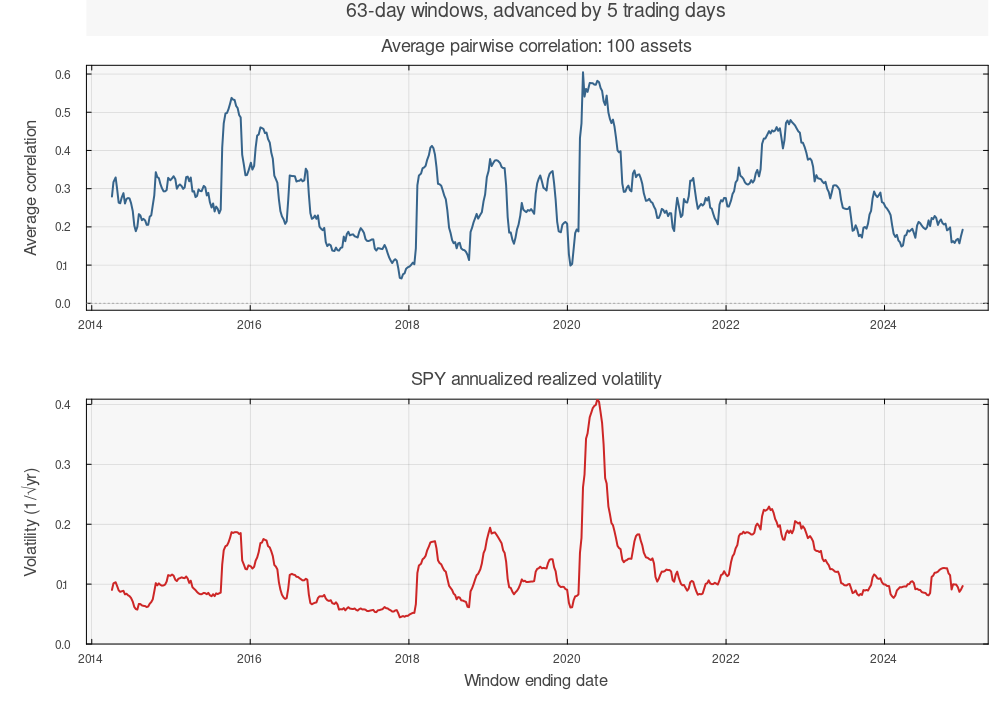

In [ ]:
let
    # Display correlations and volatility on aligned dates with separate vertical units -
    years = 2014:2:2024
    date_ticks = (Date.(years), string.(years)) # actual Date positions paired with readable year labels
    p1 = plot(
        universe_df.date, universe_df.mean_correlation;
        color = :steelblue4, legend = false, ylabel = "Average correlation",
        title = "Average pairwise correlation: $(subset_size) assets",
    )
    hline!(p1, [0.0]; color = :gray65, linestyle = :dot, linewidth = 1)
    p2 = plot(
        universe_df.date, universe_df.spy_volatility;
        color = :firebrick3, legend = false, ylabel = "Volatility (1/√yr)",
        title = "SPY annualized realized volatility", xlabel = "Window ending date",
        ylims = (0, Inf),
    )
    # link=:x shares the date axis while leaving the two vertical scales independent.
    plot(
        p1, p2; layout = (2, 1), size = (1000, 720), link = :x,
        xticks = date_ticks, left_margin = 8 * Plots.mm,
        bottom_margin = 8 * Plots.mm, titlefontsize = 12,
        plot_title = "$(correlation_window)-day windows, advanced by $(window_step) trading days",
        plot_titlefontsize = 13,
    )
end

### Compare More and Less Volatile Windows

The plot suggests that average correlation rises with SPY volatility. Let's correlate the two series and compare the average correlation in the most volatile 10% of windows with the rest, using the 90th percentile of SPY volatility as the cutoff:

In [ ]:
# Describe historical high-volatility windows using a cutoff from the complete plotted sample -
stress_quantile = 0.90; # Historical SPY-volatility percentile cutoff (fraction)

let
    ρ_series = cor(universe_df.mean_correlation, universe_df.spy_volatility) # association between window statistics
    volatility_cutoff = quantile(universe_df.spy_volatility, stress_quantile)
    stressed = universe_df.spy_volatility .> volatility_cutoff # Boolean mask; equality belongs to the other group
    remaining_mean = mean(universe_df.mean_correlation[.!stressed]) # .! selects the complementary windows
    stressed_mean = mean(universe_df.mean_correlation[stressed])
    # Report descriptive comparisons; the full-sample cutoff is not an advance trading rule.
    println("Correlation between the two plotted series: ", round(ρ_series, digits=3))
    println("SPY volatility cutoff (1/√yr): ", round(volatility_cutoff, digits=3))
    println("Average pairwise correlation by volatility group:")
    println("  At or below the cutoff: ", round(remaining_mean, digits=3))
    println("  Above the cutoff: ", round(stressed_mean, digits=3))
end

Correlation between the two plotted series: 0.861
SPY volatility cutoff (1/√yr): 0.186
Average pairwise correlation by volatility group:
  At or below the cutoff: 0.261
  Above the cutoff: 0.473


For a portfolio of long positions, higher correlations reduce diversification when weights and asset volatilities stay fixed. Those weights and volatilities also affect portfolio risk.

A constant covariance estimate summarizes its sample period. An estimate from a calm period may understate risk in volatile periods. State the window and estimator, and compare estimates across market conditions.

___

## Summary

In this example, we examined how correlation estimates depend on the observations and weights used to calculate them.

> __Key Takeaways:__
>
> * **Rolling correlations:** We estimated correlations over 63-day and 252-day windows and compared them with the full-sample value. Shorter windows reacted faster but were noisier, and a single full-sample value hid periods with different strengths or even different signs.
>
> * **Exponentially weighted correlations:** We replaced the hard window cutoff with weights that let older observations fade gradually. A smaller decay factor reacted more strongly to new data, while a factor closer to one kept more history and gave a smoother estimate.
>
> * **Correlation and market volatility:** We averaged correlations across a fixed subset of 100 assets and compared them with SPY volatility over the same windows. Average correlation was higher in the most volatile windows, so a covariance estimate from a calm period may understate risk for a portfolio of long positions.

The constant covariance rate in the multiple-asset GBM model is a simplification: one estimate may describe some historical periods better than others.

___


## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___